# 05 · 자원 최적화 데이터 탐색

## EDA 계획

1. 데이터 기간·열·결측·중복·날짜/시간 유효성을 점검합니다.
2. 15/30/45/60분과 평균 열의 수학적 관계, 날짜 파생 열의 일관성을 확인합니다.
3. 유효 시간 기록으로 날짜·시간대·요일별 패턴과 생산량 관계를 살펴봅니다.
4. 무생산 시간대의 자원 사용, 생산량 대비 지표, 기상·요금·인원 변수 관계를 확인합니다.
5. 예측 시점에 이용 가능한 변수와 최적화에 필요한 단위·제약조건을 구분합니다.


원본 데이터는 수정하지 않습니다. 위에서부터 실행하세요. 프로젝트 `.venv` 커널과 `notebooks/requirements.txt`의 패키지를 사용합니다. 수치와 도표는 전체 데이터를 기준으로 하며 표본·표시 범위를 제한하면 해당 셀에 명시합니다. 탐색 결과는 모델 성능이나 인과 효과를 의미하지 않습니다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
SEED = 42
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data').is_dir())
pd.set_option('display.max_columns', 30)
fonts = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams['font.family'] = [next((f for f in ['Malgun Gothic','AppleGothic','NanumGothic'] if f in fonts), 'DejaVu Sans'), 'DejaVu Sans']
plt.rcParams.update({'axes.unicode_minus':False, 'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False})

def quality(df, exclude=()):
    x = df.drop(columns=list(exclude), errors='ignore')
    out = pd.DataFrame({'dtype':x.dtypes.astype(str), 'missing':x.isna().sum(),
                        'missing_pct':x.isna().mean()*100, 'unique':x.nunique()})
    print(f'행 {len(df):,} / 열 {len(df.columns)} / 제외 열을 뺀 중복 {x.duplicated().sum():,}')
    display(out)
    return out

def corr_plot(df, cols, title):
    corr = df[cols].corr(method='spearman')
    fig, ax = plt.subplots(figsize=(max(7,len(cols)*.65), max(5,len(cols)*.6)))
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols)),cols,rotation=70,ha='right')
    ax.set_yticks(range(len(cols)),cols); ax.set_title(title)
    fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

def hist_grid(df, cols, title):
    fig, axes = plt.subplots(int(np.ceil(len(cols)/3)),3,figsize=(15,3.4*int(np.ceil(len(cols)/3))),squeeze=False)
    for ax,c in zip(axes.flat,cols):
        ax.hist(df[c].replace([np.inf,-np.inf],np.nan).dropna(),bins=40,color='#2563eb',alpha=.8)
        ax.set_title(c,fontsize=10); ax.set_ylabel('행 수')
    for ax in list(axes.flat)[len(cols):]: ax.set_visible(False)
    fig.suptitle(title); plt.tight_layout(); plt.show()

DATA = next((ROOT / 'data').glob('5.*'))

## 1. 품질과 시간축 점검
`시간`은 0~23의 정수로 가정하여 검사합니다. 잘못된 시간값을 다음 날짜로 넘기거나 행 순서로 복원하지 않습니다. 파일명에 augumented가 있으나 증강 방식은 제공되지 않았습니다.

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


행 6,168 / 열 18 / 제외 열을 뺀 중복 0


,dtype,missing,missing_pct,unique
날짜,int64,0,0.000000,257
시간,int64,0,0.000000,60
15분,int64,0,0.000000,166
30분,int64,0,0.000000,185
45분,int64,0,0.000000,187
60분,int64,0,0.000000,183
평균,int64,0,0.000000,176
생산량,int64,0,0.000000,1637
기온,float64,0,0.000000,439
풍속,float64,3,0.048638,70


,issue,rows
0,잘못된 날짜,0
1,잘못된 시간,48
2,전체 중복 행,0
3,날짜/시간 키 중복(첫 행 제외),5
4,유효 시각 중복(첫 행 제외),0


시간         
         count min  max
날짜                     
20210713    24  70  188
20210715    24  74  184

전체 기간: 2021-01-01 00:00:00 2021-09-14 00:00:00 유효 시간 행: 6120


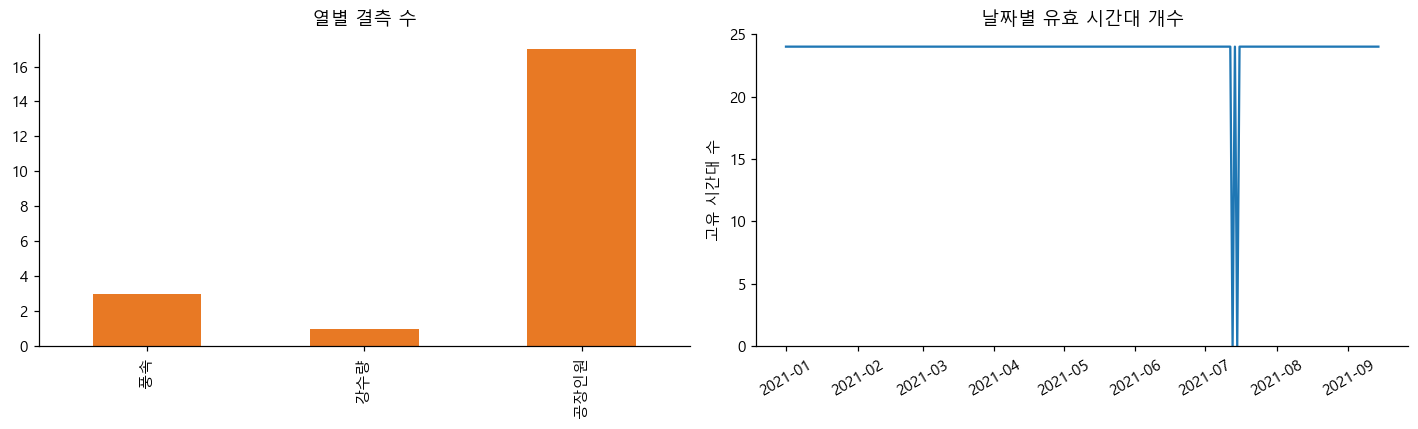

In [2]:
path=next(DATA.rglob('*.csv'));raw=pd.read_csv(path,encoding='utf-8-sig')
display(raw.head());q=quality(raw)
day=pd.to_datetime(raw['날짜'].astype(str),format='%Y%m%d',errors='coerce')
valid_hour=raw['시간'].between(0,23)&raw['시간'].mod(1).eq(0)
valid=day.notna()&valid_hour
df=raw.copy();df['date']=day;df['timestamp']=pd.NaT
df.loc[valid,'timestamp']=day[valid]+pd.to_timedelta(raw.loc[valid,'시간'],unit='h')
issues=pd.DataFrame({'issue':['잘못된 날짜','잘못된 시간','전체 중복 행','날짜/시간 키 중복(첫 행 제외)','유효 시각 중복(첫 행 제외)'],
                     'rows':[int(day.isna().sum()),int((~valid_hour).sum()),int(raw.duplicated().sum()),int(raw.duplicated(['날짜','시간']).sum()),int(df.loc[valid,'timestamp'].duplicated().sum())]})
display(issues);display(raw.loc[~valid,['날짜','시간']].groupby('날짜').agg(['count','min','max']))
valid_df=df.loc[valid].copy().sort_values('timestamp')
print('전체 기간:',day.min(),day.max(),'유효 시간 행:',len(valid_df))
coverage=valid_df.groupby('date')['시간'].nunique().reindex(pd.date_range(day.min(),day.max(),freq='D'),fill_value=0)
fig,axes=plt.subplots(1,2,figsize=(13,4))
q.missing[q.missing.gt(0)].plot.bar(ax=axes[0],color='#e87924',title='열별 결측 수')
axes[1].plot(coverage.index,coverage);axes[1].set(title='날짜별 유효 시간대 개수',ylabel='고유 시간대 수',ylim=(0,25));axes[1].tick_params(axis='x',rotation=30)
plt.tight_layout();plt.show()

## 2. 파생 열과 분포
평균이 4개 구간의 평균과 일치하는지 검사합니다. 예측 목표가 평균일 때 같은 시간의 구간값을 입력하면 목표값이 사실상 노출될 수 있습니다. 소수 인원값은 실제 인원 수인지 별도 지표인지 확인해야 합니다.

,rows
평균과 4구간 평균의 정확 일치 행,1831
평균과 4구간 평균의 차이 1 이내 행,6168
날짜와 m 불일치,0
날짜와 d 불일치,0
day와 ISO 요일 불일치,0
공장인원 소수값 행,3510


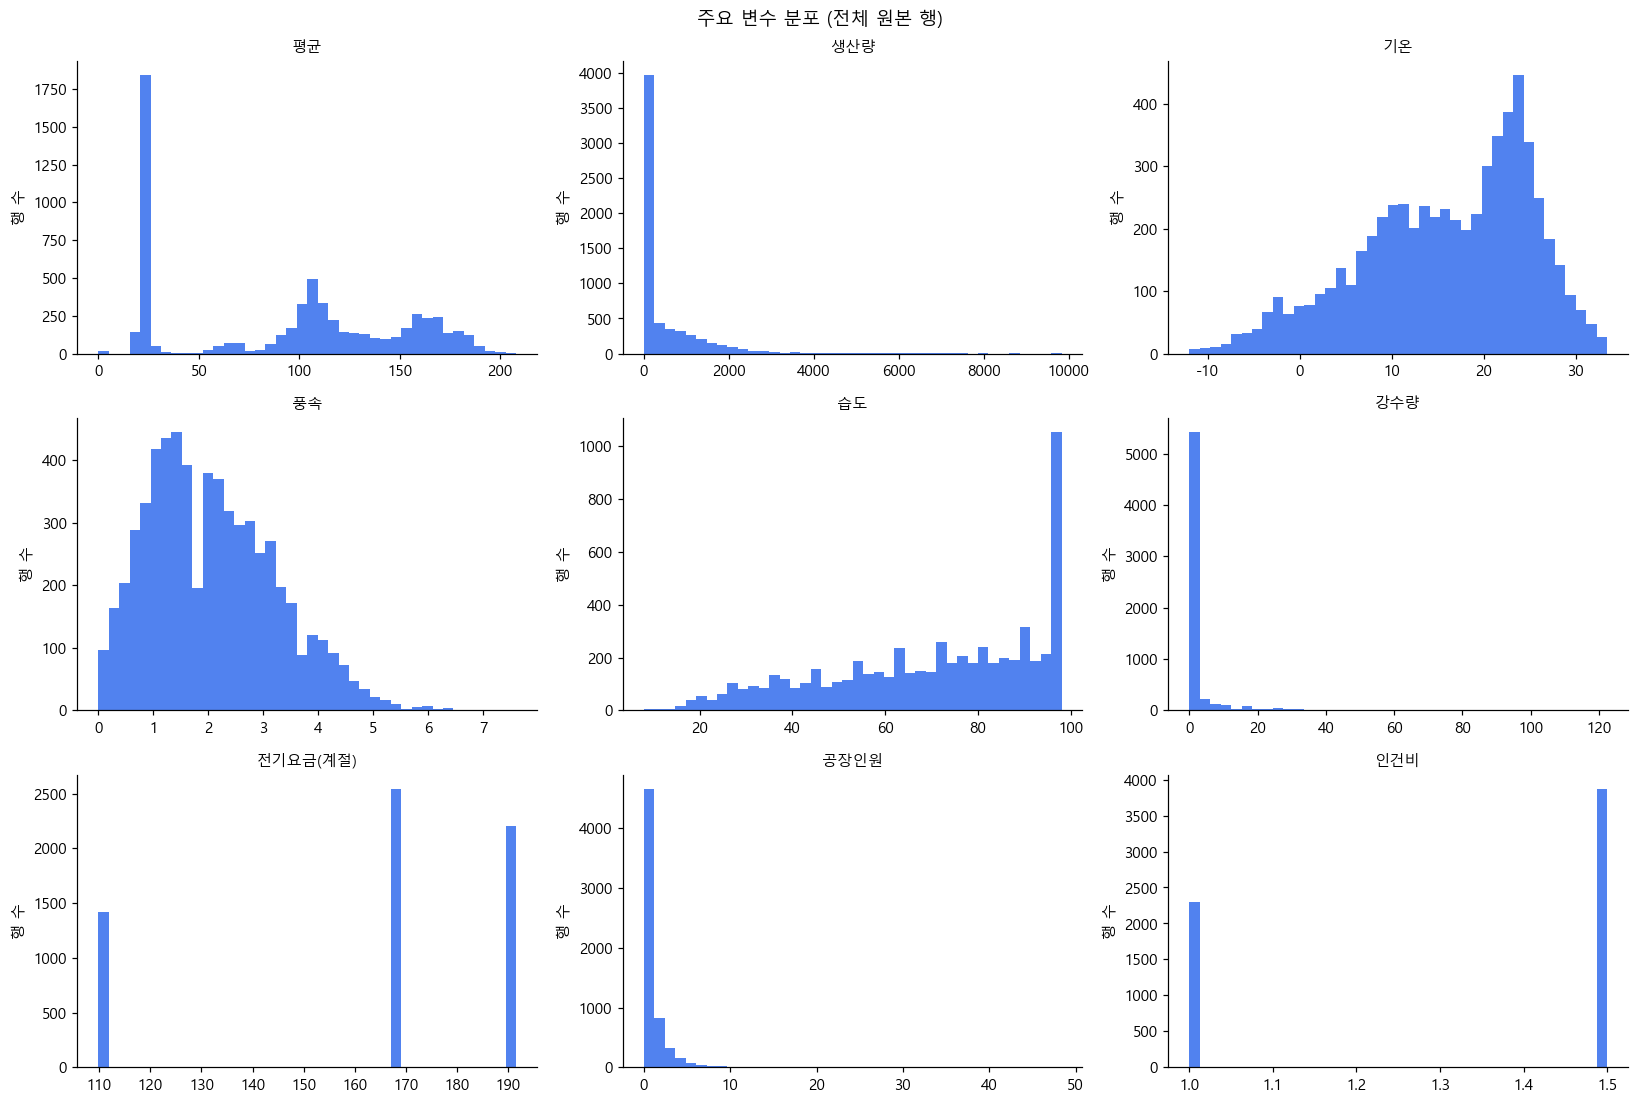

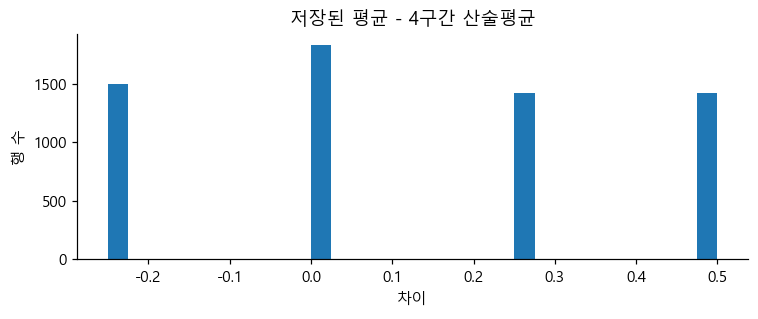

In [3]:
quarters=['15분','30분','45분','60분']
mean4=raw[quarters].mean(axis=1)
checks=pd.Series({'평균과 4구간 평균의 정확 일치 행':int(np.isclose(raw['평균'],mean4).sum()),
                  '평균과 4구간 평균의 차이 1 이내 행':int((raw['평균']-mean4).abs().le(1).sum()),
                  '날짜와 m 불일치':int((day.notna()&raw.m.ne(day.dt.month)).sum()),
                  '날짜와 d 불일치':int((day.notna()&raw.d.ne(day.dt.day)).sum()),
                  'day와 ISO 요일 불일치':int((day.notna()&raw.day.ne(day.dt.dayofweek+1)).sum()),
                  '공장인원 소수값 행':int((raw['공장인원'].notna()&raw['공장인원'].mod(1).ne(0)).sum())})
display(checks.to_frame('rows'))
hist_grid(raw,['평균','생산량','기온','풍속','습도','강수량','전기요금(계절)','공장인원','인건비'],'주요 변수 분포 (전체 원본 행)')
fig,ax=plt.subplots(figsize=(7,3));ax.hist(raw['평균']-mean4,bins=30);ax.set(title='저장된 평균 - 4구간 산술평균',xlabel='차이',ylabel='행 수');plt.tight_layout();plt.show()

## 3. 시간대·요일·날짜 패턴
이 절부터 시간 분석에는 유효 시각만 사용합니다. 일별 평균은 관측 시간의 평균이며 누락 시간은 0으로 채우지 않습니다. 평균 열의 단위가 불명확하여 에너지 총량으로 환산하지 않습니다.

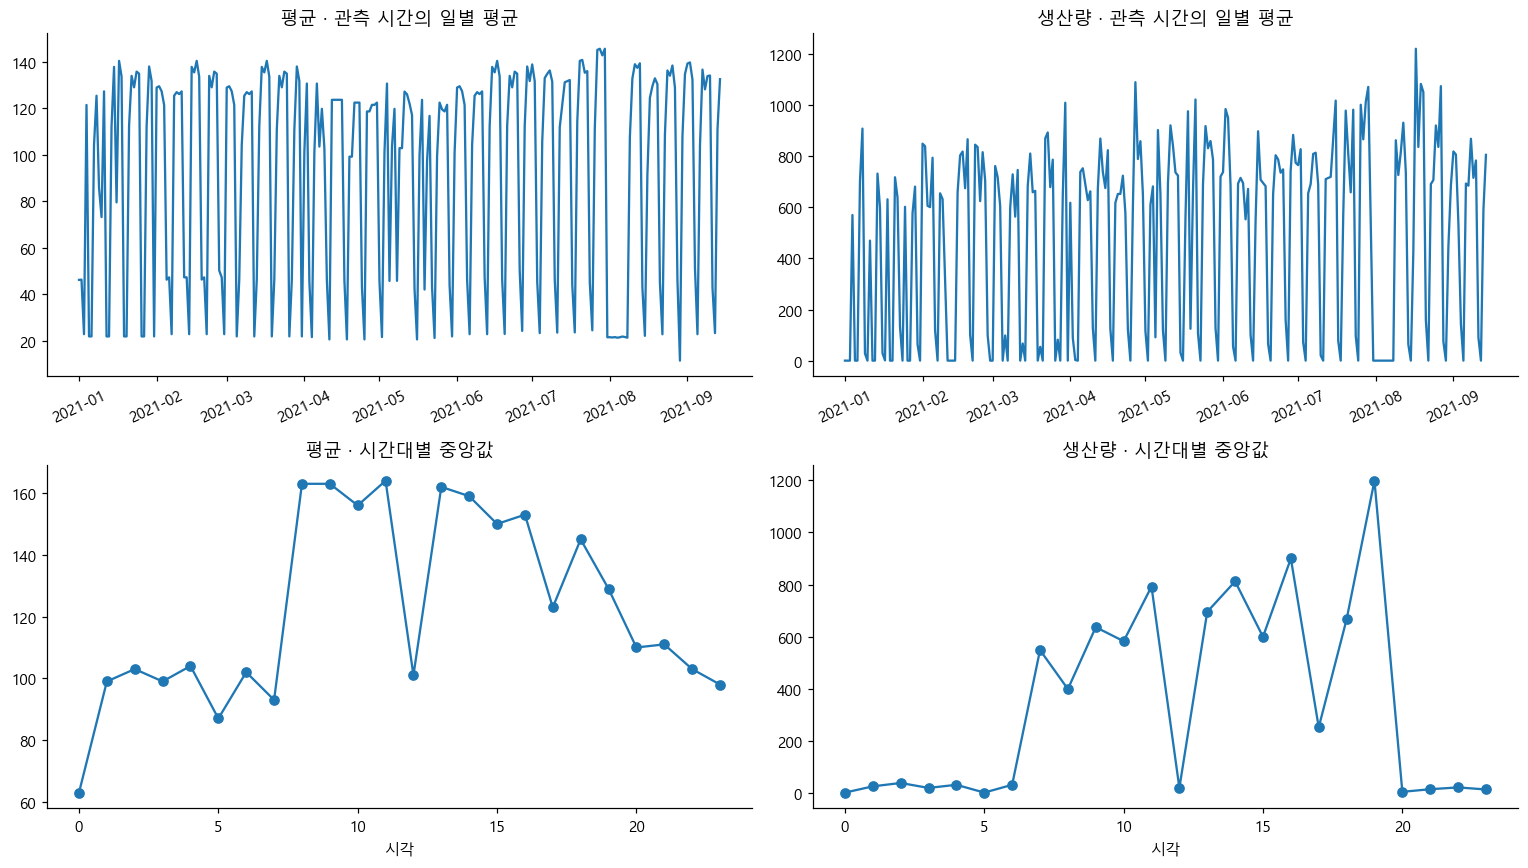

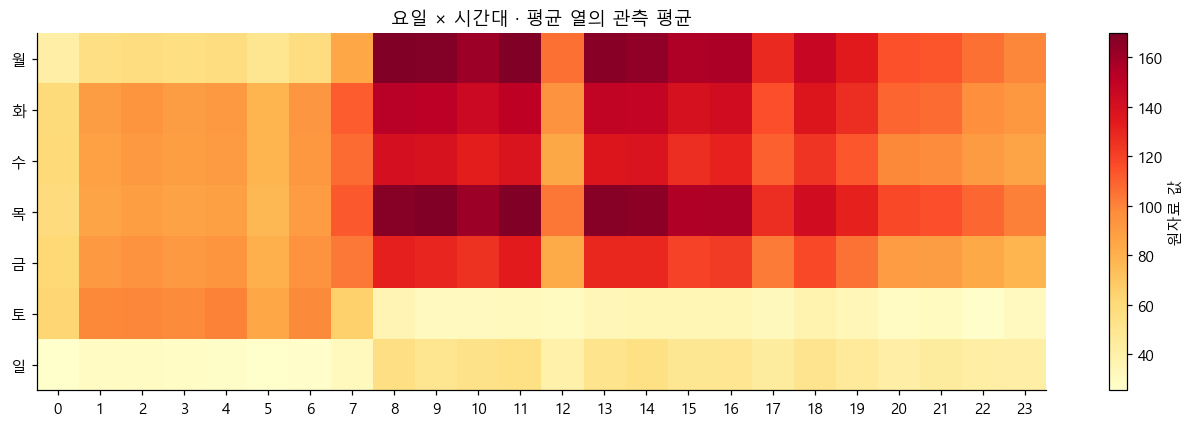

,시간 행 수
weekday,
0,888
1,864
2,864
3,840
4,888
5,888
6,888


In [4]:
valid_df['weekday']=valid_df.timestamp.dt.dayofweek
hourly=valid_df.groupby('시간')[['평균','생산량']].median()
daily=valid_df.groupby('date')[['평균','생산량']].mean()
fig,axes=plt.subplots(2,2,figsize=(14,8))
for i,c in enumerate(['평균','생산량']):
    axes[0,i].plot(daily.index,daily[c]);axes[0,i].set_title(c+' · 관측 시간의 일별 평균');axes[0,i].tick_params(axis='x',rotation=25)
    axes[1,i].plot(hourly.index,hourly[c],marker='o');axes[1,i].set_title(c+' · 시간대별 중앙값');axes[1,i].set_xlabel('시각')
plt.tight_layout();plt.show()
pivot=valid_df.pivot_table(index='weekday',columns='시간',values='평균',aggfunc='mean').reindex(index=range(7),columns=range(24))
fig,ax=plt.subplots(figsize=(12,4));im=ax.imshow(pivot,aspect='auto',cmap='YlOrRd')
ax.set_yticks(range(7),['월','화','수','목','금','토','일']);ax.set_xticks(range(24));ax.set_title('요일 × 시간대 · 평균 열의 관측 평균')
fig.colorbar(im,ax=ax,label='원자료 값');plt.tight_layout();plt.show()
display(valid_df.groupby('weekday').size().rename('시간 행 수').to_frame())

## 4. 생산량과 자원 사용 관계
생산량이 0인 시간과 양수인 시간을 분리합니다. 평균/생산량은 원자료 기준 비율로, 단위가 확인되지 않아 kWh/개 또는 비용으로 부르지 않습니다. 원인·낭비 여부는 운영 조건을 확인해야 합니다.

,rows,mean_resource,median_resource
production_state,,,
생산량 0,2609,44.538904,23.0
생산량 양수,3511,129.170037,125.0


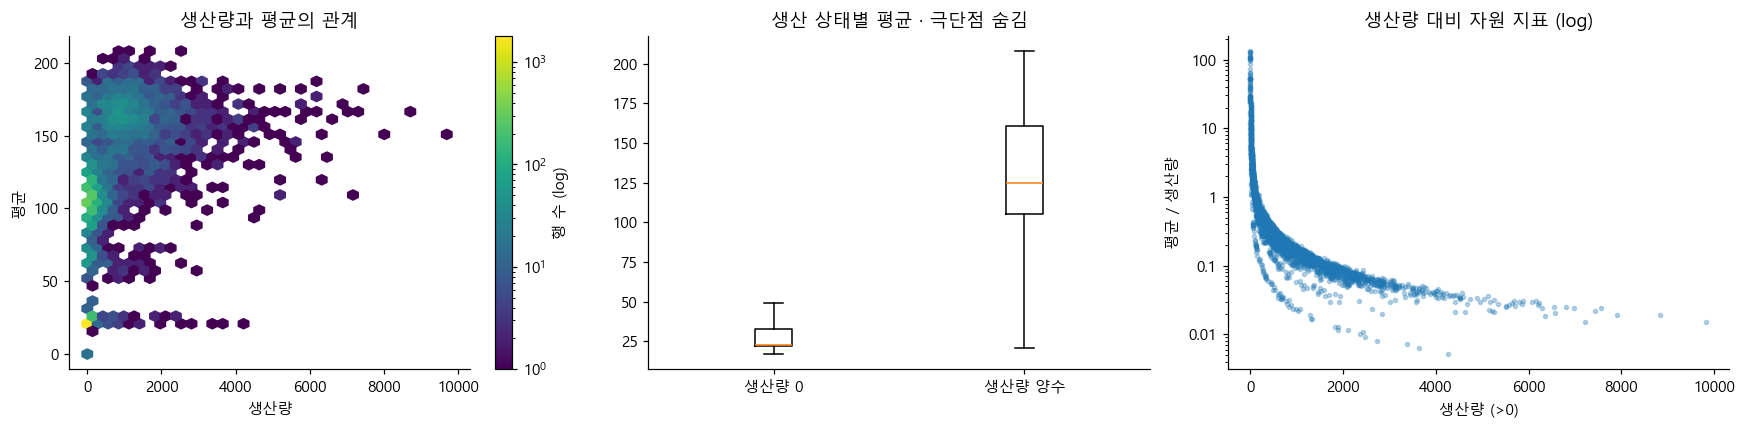

,평균 / 생산량
count,3511.000000
mean,1.983938
std,8.806005
min,0.005167
50%,0.260802
90%,2.810811
95%,6.685855
99%,36.633333
max,133.000000


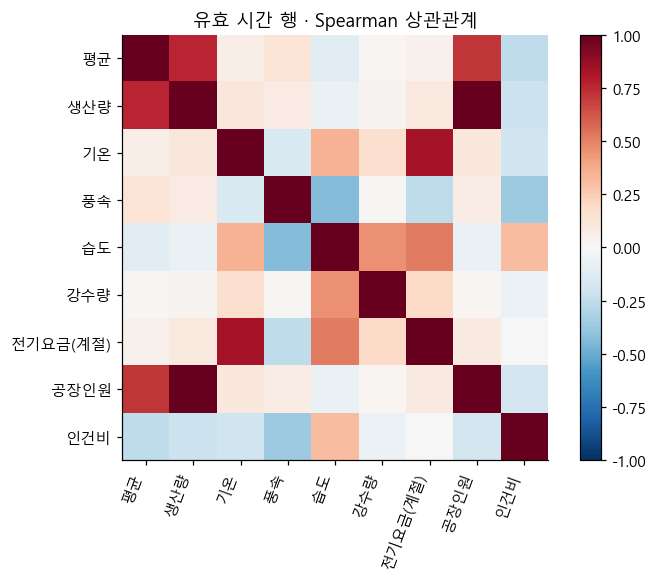

In [5]:
valid_df['production_state']=np.where(valid_df['생산량'].eq(0),'생산량 0','생산량 양수')
display(valid_df.groupby('production_state').agg(rows=('평균','size'),mean_resource=('평균','mean'),median_resource=('평균','median')))
fig,axes=plt.subplots(1,3,figsize=(16,4))
hb=axes[0].hexbin(valid_df['생산량'],valid_df['평균'],gridsize=35,mincnt=1,bins='log');fig.colorbar(hb,ax=axes[0],label='행 수 (log)')
axes[0].set(xlabel='생산량',ylabel='평균',title='생산량과 평균의 관계')
groups=list(valid_df.groupby('production_state'))
axes[1].boxplot([g['평균'] for _,g in groups],tick_labels=[k for k,_ in groups],showfliers=False);axes[1].set_title('생산 상태별 평균 · 극단점 숨김')
positive=valid_df[valid_df['생산량'].gt(0)].copy();positive['ratio']=positive['평균']/positive['생산량']
axes[2].scatter(positive['생산량'],positive.ratio,s=7,alpha=.3);axes[2].set(xlabel='생산량 (>0)',ylabel='평균 / 생산량',yscale='log',title='생산량 대비 자원 지표 (log)')
axes[2].set_yticks([.01,.1,1,10,100],['0.01','0.1','1','10','100'])
plt.tight_layout();plt.show()
display(positive.ratio.describe(percentiles=[.5,.9,.95,.99]).to_frame('평균 / 생산량'))
corr_plot(valid_df,['평균','생산량','기온','풍속','습도','강수량','전기요금(계절)','공장인원','인건비'],'유효 시간 행 · Spearman 상관관계')

## 5. 예측·최적화 주제 설계
- 전체 6,168행 중 48행은 시간 범위를 벗어나며, 2021-07-13과 2021-07-15 각 24행입니다. 유효한 6,120행 중 생산량 0은 2,609행입니다.
- 저장된 평균은 모든 행에서 4개 구간의 산술평균과 차이가 1 이내입니다. 이 관계는 목표 누출 가능성을 뒷받침합니다.
- 현재 데이터로 시간대별 자원 수요와 생산량의 관계를 탐색할 수 있습니다. 미래 수요 예측은 시간 순서 분할과 과거 값만으로 만든 지연 특징이 필요합니다.
- 같은 시간의 15/30/45/60분 값은 평균을 직접 설명하는 값이므로 평균 예측의 사전 입력에서 제외합니다. 실제 생산량·기상·인원도 예측 시점에 알려진 계획값인지 사후 실측인지 구분합니다.
- `시간` 오류 행은 원본과 대조하여 복구해야 합니다. 현재 노트북은 해당 행을 시간 분석에서만 제외하고 값 분포에는 포함합니다.
- 비용 최적화에는 전력/에너지 단위, 요금의 적용 방식, 인건비 단위, 생산능력·수요·납기·인원 제약이 필요합니다. 단위 불명의 값을 곱해 실제 비용이나 절감액을 만들지 않습니다.
- 파일명에 증강을 암시하는 표현이 있으므로 원본/증강 구분과 생성 규칙을 확보하고 같은 원본에서 파생된 행은 분할을 공유해야 합니다.